# Multimodal Short-Video Recommendation System

This project aims to build a recommendation system to improve content relevance on a mobile short-video platform. The system predicts user engagement with candidate videos, measured by watch ratio, which is then used to rank candidate videos and recommend the most relevant content to users.

## Step 5: NeuMF Model Training, Evaluation & Hybrid Model
- uses scaled feature datasets (`_scaled`.csv)

### 5.0 Setup & Imports

In [16]:
import os, json, itertools, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from IPython.display import display
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

from google.colab import drive
drive.mount('/content/drive')

BASE      = "/content/drive/MyDrive/BT4222 Data/"
ARTIFACTS = BASE + "artifacts/"
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


### 5.1 Load Artifacts

All artifacts are produced by Notebook 3. Text embeddings (`pca_title_cn`, `pca_tags_cn`) are loaded
separately and concatenated into the item feature vector at training time — they are not baked into
`video_continuous_matrix`.

In [17]:
meta = joblib.load(ARTIFACTS + 'model_meta.pkl')

# ── Interaction splits (scaled) ──
train_df = pd.read_csv(BASE + 'train_scaled.csv')
val_df   = pd.read_csv(BASE + 'val_scaled.csv')
test_df  = pd.read_csv(BASE + 'test_scaled.csv')

# ── Static feature matrices ──
user_cont  = np.load(ARTIFACTS + 'user_continuous_matrix.npy')   # (n_users, user_cont_dim)
video_cont = np.load(ARTIFACTS + 'video_continuous_matrix.npy')  # (n_items, video_cont_dim)

# ── Categorical ID arrays (for trainable embeddings) ──
user_city_arr  = np.load(ARTIFACTS + 'user_fre_city_encoded.npy')   # (n_users,)
video_root_arr = np.load(ARTIFACTS + 'video_root_id_encoded.npy')   # (n_items,)

# ── PCA text embeddings — used in Model B/C ──
pca_cn   = np.load(ARTIFACTS + f"pca_title_cn_{meta['pca_dim_cn']}.npy")
pca_tags = np.load(ARTIFACTS + f"pca_tags_cn_{meta['pca_dim_tags']}.npy")

# ── Scale PCA arrays (fit on train videos only) ──
# PCA components have zero mean but unequal variance across components.
# StandardScaler ensures the 128 title dims don't dominate the 5 metadata scalars.
train_pids       = set(train_df['pid'].unique())
train_video_mask = np.array([i in train_pids for i in range(pca_cn.shape[0])])

pca_cn_scaler   = StandardScaler()
pca_tags_scaler = StandardScaler()
pca_cn_scaled   = pca_cn_scaler.fit(pca_cn[train_video_mask]).transform(pca_cn).astype(np.float32)
pca_tags_scaled = pca_tags_scaler.fit(pca_tags[train_video_mask]).transform(pca_tags).astype(np.float32)
joblib.dump(pca_cn_scaler,   ARTIFACTS + 'pca_cn_scaler.pkl')
joblib.dump(pca_tags_scaler, ARTIFACTS + 'pca_tags_scaler.pkl')

video_text = np.hstack([pca_cn_scaled, pca_tags_scaled])

# ── Dimensions ──
NUM_USERS       = meta['n_users']
NUM_ITEMS       = meta['n_items']
N_CITY          = int(user_city_arr.max()) + 1
N_ROOT          = int(video_root_arr.max()) + 1
USER_CONT_DIM   = user_cont.shape[1]
VIDEO_CONT_DIM  = video_cont.shape[1]
VIDEO_TEXT_DIM  = video_text.shape[1]
INTERACTION_DIM = len(meta['interaction_feature_cols'])
INTERACTION_COLS = meta['interaction_feature_cols']

print(f"Users: {NUM_USERS:,}  |  Items: {NUM_ITEMS:,}")
print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"User continuous  : {USER_CONT_DIM}d   |  City classes  : {N_CITY}")
print(f"Video continuous : {VIDEO_CONT_DIM}d    |  Root classes  : {N_ROOT}")
print(f"Video text (B/C) : {VIDEO_TEXT_DIM}d  |  Interaction   : {INTERACTION_DIM}d")

Users: 10,000  |  Items: 153,561
Train: 800,827  |  Val: 128,091  |  Test: 90,650
User continuous  : 22d   |  City classes  : 275
Video continuous : 5d    |  Root classes  : 36
Video text (B/C) : 192d  |  Interaction   : 24d


### 5.2 Dataset Classes

Two dataset classes:
- `IDOnlyDataset` — returns `(user_id, item_id, target, weight)` for Model A
- `FullDataset` — additionally returns the per-interaction context feature vector for Models B & C

Time-decay weights pre-computed here: `weight = exp(-λ · days_ago)`, λ=0.0 (best from Notebook 4 validation).

In [18]:
DECAY_LAMBDA = 0.0   # best λ from caption filtering ablation

def compute_decay_weights(df: pd.DataFrame, lam: float) -> np.ndarray:
    """Exponential time-decay weights: w_i = exp(-λ · days_ago_i)."""
    et       = df['exposed_time'].values.astype(np.float64)
    days_ago = (et.max() - et) / 86400.0
    return np.exp(-lam * days_ago).astype(np.float32)


class IDOnlyDataset(Dataset):
    """Model A: user/item IDs + target + weight."""
    def __init__(self, df: pd.DataFrame, weights: np.ndarray):
        self.uids    = torch.tensor(df['user_id'].values,     dtype=torch.long)
        self.iids    = torch.tensor(df['pid'].values,         dtype=torch.long)
        self.targets = torch.tensor(df['watch_ratio'].values, dtype=torch.float32)
        self.weights = torch.tensor(weights,                  dtype=torch.float32)

    def __len__(self): return len(self.targets)

    def __getitem__(self, idx):
        return self.uids[idx], self.iids[idx], self.targets[idx], self.weights[idx]


class FullDataset(Dataset):
    """Models B & C: IDs + interaction context + target + weight."""
    def __init__(self, df: pd.DataFrame, weights: np.ndarray, ctx_cols: list):
        self.uids    = torch.tensor(df['user_id'].values,     dtype=torch.long)
        self.iids    = torch.tensor(df['pid'].values,         dtype=torch.long)
        self.targets = torch.tensor(df['watch_ratio'].values, dtype=torch.float32)
        self.weights = torch.tensor(weights,                  dtype=torch.float32)
        self.context = torch.tensor(df[ctx_cols].values,      dtype=torch.float32)

    def __len__(self): return len(self.targets)

    def __getitem__(self, idx):
        return (self.uids[idx], self.iids[idx],
                self.context[idx], self.targets[idx], self.weights[idx])


def make_loaders(train_df, val_df, test_df, batch_size, model_type='A'):
    """Build DataLoaders for the given model type ('A' or 'BC')."""
    w_train = compute_decay_weights(train_df, DECAY_LAMBDA)
    w_val   = compute_decay_weights(val_df,   DECAY_LAMBDA)
    w_test  = compute_decay_weights(test_df,  DECAY_LAMBDA)

    if model_type == 'A':
        DS = IDOnlyDataset
        kw = {}
    else:
        DS = FullDataset
        kw = {'ctx_cols': INTERACTION_COLS}

    tr = DataLoader(DS(train_df, w_train, **kw), batch_size=batch_size,
                    shuffle=True,  num_workers=2, pin_memory=True)
    va = DataLoader(DS(val_df,   w_val,   **kw), batch_size=batch_size*2,
                    shuffle=False, num_workers=2)
    te = DataLoader(DS(test_df,  w_test,  **kw), batch_size=batch_size*2,
                    shuffle=False, num_workers=2)
    return tr, va, te

print("✓ Dataset classes defined.")

✓ Dataset classes defined.


### 5.3 Model Architectures

All three models share the NeuMF backbone (He et al., 2017):
- **GMF branch**: element-wise product of user and item embeddings — captures linear interaction patterns
- **MLP branch**: concatenation of user and item representations through deep layers — captures non-linear patterns
- **Head**: concatenates GMF and MLP outputs → linear → sigmoid → scaled to [0, 2]

Overfitting controls applied across all models:
- Separate GMF / MLP embeddings (more expressive, standard NeuMF)
- BatchNorm between every MLP layer
- Dropout after every BatchNorm
- L2 weight decay in Adam optimiser
- Gradient clipping (max norm = 1.0)
- Early stopping on val MSE

| Model | Extra features |
|---|---|
| **A — ID only** | Pure CF baseline |
| **B — Static** | + user continuous matrix + city embedding + video continuous matrix + root embedding + text embeddings (title_cn 128d + tags_cn 64d) |
| **C — Full context** | B + dynamic interaction features (24d) |

In [19]:
# ── Shared building block ────────────────────────────────────────────────────

def build_mlp(input_dim: int, hidden_dims: tuple, dropout: float) -> nn.Sequential:
    """
    MLP block: Linear → BatchNorm → ReLU → Dropout, repeated.
    BatchNorm before activation stabilises training and reduces internal covariate shift.
    """
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers += [
            nn.Linear(prev, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        prev = h
    return nn.Sequential(*layers)


def init_weights(module: nn.Module):
    """Xavier uniform for linear layers, normal(0, 0.01) for embeddings."""
    if isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, std=0.01)
    elif isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.BatchNorm1d):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


# ── Model A: ID-Only NeuMF ────────────────────────────────────────────────────

class ModelA(nn.Module):
    """
    NeuMF with ID embeddings only.
    Separate embeddings for GMF and MLP branches as in the original paper.
    """
    def __init__(self, num_users, num_items, emb_dim, mlp_dims, dropout):
        super().__init__()
        # GMF branch
        self.user_emb_gmf = nn.Embedding(num_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(num_items, emb_dim)
        # MLP branch
        self.user_emb_mlp = nn.Embedding(num_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(num_items, emb_dim)

        self.mlp  = build_mlp(2 * emb_dim, mlp_dims, dropout)
        self.head = nn.Linear(emb_dim + mlp_dims[-1], 1)
        self.apply(init_weights)

    def forward(self, uid, iid, _ctx=None):
        gmf     = self.user_emb_gmf(uid) * self.item_emb_gmf(iid)
        mlp_in  = torch.cat([self.user_emb_mlp(uid), self.item_emb_mlp(iid)], dim=-1)
        mlp_out = self.mlp(mlp_in)
        out     = self.head(torch.cat([gmf, mlp_out], dim=-1)).squeeze(-1)
        return torch.sigmoid(out) * 2.0


# ── Models B & C: Feature-Enhanced NeuMF ─────────────────────────────────────

class ModelBC(nn.Module):
    """
    NeuMF with static side features (Model B) and optional interaction context (Model C).

    Architecture:
      User side  : continuous matrix + city embedding → user_proj (→ emb_dim)
      Item side  : continuous matrix + text embeddings + root embedding → item_proj (→ emb_dim)
      GMF        : (user_emb_gmf + user_proj) ⊙ (item_emb_gmf + item_proj)
      MLP input  : [user_emb_mlp, item_emb_mlp, user_proj, item_proj, (ctx_proj)]
      Head       : [gmf, mlp_out, (ctx_proj)] → Linear → sigmoid × 2

    Feature residuals are added to ID embeddings in the GMF branch so that
    side information can correct the collaborative signal without overriding it.
    """
    def __init__(
        self,
        num_users, num_items, emb_dim,
        user_cont_dim, n_city,
        video_cont_dim, video_text_dim, n_root,
        mlp_dims, dropout,
        use_context=False, interaction_dim=0,
    ):
        super().__init__()
        self.use_context = use_context

        # ── Buffers (registered so they move to GPU with .to(device)) ──
        # Loaded in forward via direct indexing — avoids DataLoader memory pressure
        # for large static matrices. Registered as buffers (not parameters).
        # Actual tensors are set after construction via register_buffer calls externally.
        self._user_cont_dim  = user_cont_dim
        self._video_cont_dim = video_cont_dim
        self._video_text_dim = video_text_dim

        # ── ID embeddings (separate GMF / MLP branches) ──
        self.user_emb_gmf = nn.Embedding(num_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(num_items, emb_dim)
        self.user_emb_mlp = nn.Embedding(num_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(num_items, emb_dim)

        # ── Categorical side embeddings ──
        self.city_emb = nn.Embedding(n_city, emb_dim // 2)
        self.root_emb = nn.Embedding(n_root, emb_dim // 2)

        # ── Feature projection networks ──
        user_feat_dim  = user_cont_dim + emb_dim // 2          # cont + city_emb
        item_feat_dim  = video_cont_dim + video_text_dim + emb_dim // 2  # cont + text + root_emb

        self.user_proj = nn.Sequential(
            nn.Linear(user_feat_dim, emb_dim * 2),
            nn.BatchNorm1d(emb_dim * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(emb_dim * 2, emb_dim),
        )
        self.item_proj = nn.Sequential(
            nn.Linear(item_feat_dim, emb_dim * 2),
            nn.BatchNorm1d(emb_dim * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(emb_dim * 2, emb_dim),
        )

        # ── Context network (Model C only) ──
        self.ctx_dim = 0
        if use_context:
            self.ctx_dim = emb_dim // 2
            self.ctx_proj = nn.Sequential(
                nn.Linear(interaction_dim, emb_dim),
                nn.BatchNorm1d(emb_dim), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(emb_dim, self.ctx_dim),
            )

        # ── Main MLP ──
        mlp_in_dim = 4 * emb_dim + self.ctx_dim
        self.mlp  = build_mlp(mlp_in_dim, mlp_dims, dropout)

        # ── Regression head ──
        head_in_dim = emb_dim + mlp_dims[-1] + self.ctx_dim
        self.head   = nn.Linear(head_in_dim, 1)

        self.apply(init_weights)

    def forward(self, uid, iid, ctx=None):
        # ── Look up static features from registered buffers ──
        u_cont   = self.user_cont[uid]                      # (B, user_cont_dim)
        i_cont   = self.item_cont[iid]                      # (B, video_cont_dim)
        i_text   = self.item_text[iid]                      # (B, video_text_dim)
        u_city   = self.city_emb(self.user_city[uid])       # (B, emb//2)
        i_root   = self.root_emb(self.item_root[iid])       # (B, emb//2)

        # ── Feature projections ──
        u_feat = self.user_proj(torch.cat([u_cont, u_city], dim=-1))   # (B, emb)
        i_feat = self.item_proj(torch.cat([i_cont, i_text, i_root], dim=-1))  # (B, emb)

        # ── GMF: residual-corrected embeddings ──
        gmf = (self.user_emb_gmf(uid) + u_feat) * (self.item_emb_gmf(iid) + i_feat)

        # ── MLP input ──
        mlp_parts = [self.user_emb_mlp(uid), self.item_emb_mlp(iid), u_feat, i_feat]
        head_parts = [gmf]

        if self.use_context and ctx is not None:
            ctx_out = self.ctx_proj(ctx)
            mlp_parts.append(ctx_out)
            head_parts.append(ctx_out)

        mlp_out = self.mlp(torch.cat(mlp_parts, dim=-1))
        head_parts.append(mlp_out)

        out = self.head(torch.cat(head_parts, dim=-1)).squeeze(-1)
        return torch.sigmoid(out) * 2.0


def attach_buffers(model: ModelBC,
                   user_cont, video_cont, video_text,
                   user_city_arr, video_root_arr):
    """Register static matrices as non-trainable buffers on the model."""
    model.register_buffer('user_cont',  torch.tensor(user_cont,      dtype=torch.float32))
    model.register_buffer('item_cont',  torch.tensor(video_cont,     dtype=torch.float32))
    model.register_buffer('item_text',  torch.tensor(video_text,     dtype=torch.float32))
    model.register_buffer('user_city',  torch.tensor(user_city_arr,  dtype=torch.long))
    model.register_buffer('item_root',  torch.tensor(video_root_arr, dtype=torch.long))
    return model

print("✓ Model architectures defined.")

✓ Model architectures defined.


### 5.4 Training Utilities

In [20]:
MSE_NONE = nn.MSELoss(reduction='none')

def weighted_mse(pred, target, weight):
    """Time-decay weighted MSE. Used for backprop."""
    return (MSE_NONE(pred, target) * weight).mean()

def unweighted_mse(pred, target):
    """Standard MSE. Used for model selection on val set."""
    return MSE_NONE(pred, target).mean().item()

def run_epoch(model, loader, optimizer=None):
    """
    One training or evaluation epoch.
    - Training (optimizer not None): weighted MSE backprop.
    - Evaluation: returns unweighted MSE for fair model comparison.
    Returns (weighted_loss, unweighted_loss) — unweighted_loss is used for early stopping.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_w, total_uw, n = 0.0, 0.0, 0
    ctx_mgr = torch.enable_grad() if is_train else torch.no_grad()

    with ctx_mgr:
        for batch in loader:
            has_ctx = len(batch) == 5
            if has_ctx:
                uid, iid, ctx, target, weight = [x.to(device) for x in batch]
                pred = model(uid, iid, ctx)
            else:
                uid, iid, target, weight = [x.to(device) for x in batch]
                pred = model(uid, iid)

            w_loss  = weighted_mse(pred, target, weight)
            uw_loss = unweighted_mse(pred, target)

            if is_train:
                optimizer.zero_grad()
                w_loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            b = len(target)
            total_w  += w_loss.item()  * b
            total_uw += uw_loss        * b
            n        += b

    return total_w / n, total_uw / n


def train_model(model, train_loader, val_loader, lr, weight_decay,
                epochs=60, patience=7, save_path=None):
    """
    Train with Adam + ReduceLROnPlateau + early stopping on val unweighted MSE.
    Returns best model state and training history.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3)

    best_val  = float('inf')
    patience_ctr = 0
    best_state   = None
    history      = {'train_w': [], 'val_uw': []}

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params: {n_params:,}")

    for epoch in range(1, epochs + 1):
        t_w, _   = run_epoch(model, train_loader, optimizer)
        _,  v_uw = run_epoch(model, val_loader)
        scheduler.step(v_uw)
        history['train_w'].append(t_w)
        history['val_uw'].append(v_uw)

        lr_now = optimizer.param_groups[0]['lr']
        marker = ''
        if v_uw < best_val:
            best_val     = v_uw
            patience_ctr = 0
            best_state   = deepcopy(model.state_dict())
            if save_path:
                torch.save(best_state, save_path)
            marker = ' ✓'
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stop @ epoch {epoch}  best val MSE: {best_val:.4f}")
                break

        if epoch % 5 == 0 or marker:
            print(f"  Ep {epoch:03d} | train(w): {t_w:.4f} | val MSE: {v_uw:.4f} "                  f"| lr: {lr_now:.1e}{marker}")

    model.load_state_dict(best_state)
    return model, history, best_val


@torch.no_grad()
def get_predictions(model, loader):
    """Collect all predictions and targets from a DataLoader."""
    model.eval()
    preds, targets = [], []
    for batch in loader:
        has_ctx = len(batch) == 5
        if has_ctx:
            uid, iid, ctx, target, _ = batch
            pred = model(uid.to(device), iid.to(device), ctx.to(device))
        else:
            uid, iid, target, _ = batch
            pred = model(uid.to(device), iid.to(device))
        preds.append(pred.cpu())
        targets.append(target)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

print("✓ Training utilities defined.")

✓ Training utilities defined.


### 5.5 Ranking Evaluation

Mirrors Notebook 4 exactly: per-user ranking of the candidate set, binary relevance at threshold 0.5.

In [21]:
def dcg_at_k(rel, k):
    rel = np.asarray(rel, dtype=np.float64)[:k]
    return np.sum((2**rel - 1) / np.log2(np.arange(2, rel.size + 2))) if rel.size else 0.0

def ndcg_at_k(rel, ideal, k):
    idcg = dcg_at_k(ideal, k)
    return dcg_at_k(rel, k) / idcg if idcg > 0 else 0.0

def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if k > 0 else 0.0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0.0

def hit_rate_at_k(rec, rel, k):
    return 1.0 if set(rec[:k]) & set(rel) else 0.0

def reciprocal_rank(rec, rel, k):
    rel_set = set(rel)
    for rank, item in enumerate(rec[:k], 1):
        if item in rel_set: return 1.0 / rank
    return 0.0

def average_precision(rec, rel, k):
    rel_set, hits, s = set(rel), 0, 0.0
    for rank, item in enumerate(rec[:k], 1):
        if item in rel_set:
            hits += 1; s += hits / rank
    return s / len(rel_set) if rel_set else 0.0

def catalog_coverage(all_recs, n_items):
    return len(set(all_recs)) / n_items if n_items else 0.0


class RankingEvaluator:
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def evaluate(self, eval_df, k_values=(5, 10, 20), n_items=None, n_users=None):
        """
        eval_df must have columns: user_id, pid, watch_ratio, predicted_score.
        Ranks candidates per user by predicted_score descending.
        """
        metrics   = {k: {m: [] for m in ['ndcg','prec','rec','hr','mrr','map']}
                     for k in k_values}
        all_recs  = []
        n_covered = 0

        for uid, udata in eval_df.groupby('user_id'):
            if len(udata) < 2: continue
            udata = udata.sort_values('predicted_score', ascending=False)
            rec   = udata['pid'].tolist()
            rel   = udata[udata['watch_ratio'] >= self.threshold]['pid'].tolist()
            if not rel: continue

            n_covered += 1
            all_recs.extend(rec)
            bin_rel = (udata['watch_ratio'] >= self.threshold).astype(int).tolist()
            ideal   = sorted(bin_rel, reverse=True)

            for k in k_values:
                metrics[k]['ndcg'].append(ndcg_at_k(bin_rel, ideal, k))
                metrics[k]['prec'].append(precision_at_k(rec, rel, k))
                metrics[k]['rec'].append(recall_at_k(rec, rel, k))
                metrics[k]['hr'].append(hit_rate_at_k(rec, rel, k))
                metrics[k]['mrr'].append(reciprocal_rank(rec, rel, k))
                metrics[k]['map'].append(average_precision(rec, rel, k))

        out = {}
        name_map = {'ndcg':'NDCG','prec':'Precision','rec':'Recall',
                    'hr':'HitRate','mrr':'MRR','map':'MAP'}
        for k in k_values:
            for mk, mn in name_map.items():
                vals = metrics[k][mk]
                out[f'{mn}@{k}'] = float(np.mean(vals)) if vals else 0.0

        if n_items: out['CatalogCoverage'] = catalog_coverage(all_recs, n_items)
        if n_users: out['UserCoverage']    = n_covered / n_users
        return out

    def print_results(self, label, res, k_values=(5, 10, 20)):
        print(f"  [{label}]")
        hdr = f"  {'Metric':<16}" + ''.join(f'@{k:<9}' for k in k_values)
        print(hdr)
        print('  ' + '-' * (16 + 10 * len(k_values)))
        for m in ['NDCG','Precision','Recall','HitRate','MRR','MAP']:
            row = f"  {m:<16}"
            for k in k_values:
                row += f"{res.get(f'{m}@{k}', 0):<10.4f}"
            print(row)
        if 'CatalogCoverage' in res:
            print(f"  CatalogCoverage: {res['CatalogCoverage']:.4f} "                  f"({res['CatalogCoverage']*100:.1f}%)")
        if 'UserCoverage' in res:
            print(f"  UserCoverage   : {res['UserCoverage']:.4f} "                  f"({res['UserCoverage']*100:.1f}%)")
        print()


K_VALUES  = (5, 10, 20)
evaluator = RankingEvaluator(threshold=0.5)

def full_eval(model, loader, split_df, label, split_name):
    """Run regression + ranking evaluation and print results."""
    preds, targets = get_predictions(model, loader)
    mse  = float(np.mean((preds - targets) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(preds - targets)))

    eval_df = split_df[['user_id', 'pid', 'watch_ratio']].copy()
    eval_df['predicted_score'] = preds
    rank_res = evaluator.evaluate(eval_df, K_VALUES, NUM_ITEMS, NUM_USERS)

    print(f"\n  [{label} — {split_name}]")
    print(f"  MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}")
    evaluator.print_results(f"{label} {split_name}", rank_res, K_VALUES)
    return {'mse': mse, 'rmse': rmse, 'mae': mae, **rank_res}, preds

print("✓ Ranking evaluator defined.")


✓ Ranking evaluator defined.


### 5.6 Hyperparameter Tuning (Manual Grid Search on Val Set)

Grid: 8 configs — `embedding_dim` × `mlp_dims` × `dropout`. Learning rate and weight decay are fixed
based on prior experience. The same grid is used for all three models for fair comparison.

Selection criterion: **Val NDCG@10** (ranking quality), not val MSE.
This aligns model selection with the final evaluation objective.

In [22]:
FIXED_LR           = 5e-4
FIXED_WEIGHT_DECAY = 1e-4
FIXED_BATCH        = 2048
FIXED_EPOCHS       = 60
FIXED_PATIENCE     = 8

GRID = list(itertools.product(
    [16, 32],                           # embedding_dim
    [(128, 64), (256, 128, 64)],        # mlp_dims
    [0.2, 0.3],                         # dropout
))

print(f"Grid size: {len(GRID)} configs")
print(f"Fixed: lr={FIXED_LR}, weight_decay={FIXED_WEIGHT_DECAY}, "      f"batch={FIXED_BATCH}, epochs={FIXED_EPOCHS}, patience={FIXED_PATIENCE}")
for i, (emb, mlp, drop) in enumerate(GRID):
    print(f"  Config {i+1}: emb={emb}  mlp={mlp}  dropout={drop}")

Grid size: 8 configs
Fixed: lr=0.0005, weight_decay=0.0001, batch=2048, epochs=60, patience=8
  Config 1: emb=16  mlp=(128, 64)  dropout=0.2
  Config 2: emb=16  mlp=(128, 64)  dropout=0.3
  Config 3: emb=16  mlp=(256, 128, 64)  dropout=0.2
  Config 4: emb=16  mlp=(256, 128, 64)  dropout=0.3
  Config 5: emb=32  mlp=(128, 64)  dropout=0.2
  Config 6: emb=32  mlp=(128, 64)  dropout=0.3
  Config 7: emb=32  mlp=(256, 128, 64)  dropout=0.2
  Config 8: emb=32  mlp=(256, 128, 64)  dropout=0.3


### 5.7 Model A — ID-Only NeuMF

Baseline: pure collaborative filtering with no side features.

In [23]:
print("=" * 65)
print("HYPERPARAMETER SEARCH — Model A")
print("=" * 65)

train_a, val_a, test_a = make_loaders(train_df, val_df, test_df,
                                       FIXED_BATCH, model_type='A')

_cached_a = (os.path.exists(ARTIFACTS + 'model_a_best.pt')
             and os.path.exists(ARTIFACTS + 'model_a_cfg.pkl'))

if _cached_a:
    print("⚡ Cached artifacts found — skipping grid search.")
else:
    best_cfg_a, best_ndcg_a, best_model_a = None, -1, None
    grid_results_a = []

    for cfg_idx, (emb, mlp, drop) in enumerate(GRID):
        print(f"\nConfig {cfg_idx+1}/{len(GRID)}: emb={emb} mlp={mlp} drop={drop}")
        model = ModelA(NUM_USERS, NUM_ITEMS, emb, mlp, drop).to(device)
        model, hist, best_val_mse = train_model(
            model, train_a, val_a,
            lr=FIXED_LR, weight_decay=FIXED_WEIGHT_DECAY,
            epochs=FIXED_EPOCHS, patience=FIXED_PATIENCE,
            save_path=ARTIFACTS + f'tmp_a_cfg{cfg_idx}.pt'
        )
        preds_v, targets_v = get_predictions(model, val_a)
        eval_df_v = val_df[['user_id','pid','watch_ratio']].copy()
        eval_df_v['predicted_score'] = preds_v
        rank_v = evaluator.evaluate(eval_df_v, K_VALUES, NUM_ITEMS, NUM_USERS)
        ndcg_v = rank_v['NDCG@10']

        grid_results_a.append({
            'emb': emb, 'mlp': str(mlp), 'drop': drop,
            'val_mse': best_val_mse, 'val_ndcg10': ndcg_v
        })
        print(f"  → Val MSE: {best_val_mse:.4f}  Val NDCG@10: {ndcg_v:.4f}")

        if ndcg_v > best_ndcg_a:
            best_ndcg_a  = ndcg_v
            best_cfg_a   = (emb, mlp, drop)
            best_model_a = deepcopy(model.state_dict())

    df_grid_a = pd.DataFrame(grid_results_a)
    print("\n── Grid Search Results — Model A ──")
    display(df_grid_a.sort_values('val_ndcg10', ascending=False).style.highlight_max(
        subset=['val_ndcg10'], color='#d4edda').highlight_min(
        subset=['val_mse'], color='#d4edda').format(precision=4))

    print(f"\n★ Best config A: emb={best_cfg_a[0]}, mlp={best_cfg_a[1]}, drop={best_cfg_a[2]}")
    print(f"  Val NDCG@10 = {best_ndcg_a:.4f}")

HYPERPARAMETER SEARCH — Model A
⚡ Cached artifacts found — skipping grid search.


In [24]:
if _cached_a:
    cfg_a = joblib.load(ARTIFACTS + 'model_a_cfg.pkl')
    emb_a, mlp_a, drop_a = cfg_a['emb'], cfg_a['mlp'], cfg_a['drop']
    model_a = ModelA(NUM_USERS, NUM_ITEMS, emb_a, mlp_a, drop_a).to(device)
    model_a.load_state_dict(torch.load(ARTIFACTS + 'model_a_best.pt', map_location=device))
    print(f"⚡ Loaded Model A from cache: emb={emb_a}, mlp={mlp_a}, drop={drop_a}")
else:
    emb_a, mlp_a, drop_a = best_cfg_a
    model_a = ModelA(NUM_USERS, NUM_ITEMS, emb_a, mlp_a, drop_a).to(device)
    model_a.load_state_dict(best_model_a)

print("=" * 65)
print("FINAL EVALUATION — Model A")
print("=" * 65)
model_a.eval()
val_res_a,  preds_val_a  = full_eval(model_a, val_a,  val_df,  'Model A', 'VAL')
test_res_a, preds_test_a = full_eval(model_a, test_a, test_df, 'Model A', 'TEST')
if not _cached_a:
    torch.save(model_a.state_dict(), ARTIFACTS + 'model_a_best.pt')
print("✓ Model A ready.")

⚡ Loaded Model A from cache: emb=16, mlp=(128, 64), drop=0.3
FINAL EVALUATION — Model A

  [Model A — VAL]
  MSE: 0.2788  RMSE: 0.5280  MAE: 0.4226
  [Model A VAL]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.6952    0.7262    0.7656    
  Precision       0.5486    0.4470    0.3299    
  Recall          0.5259    0.7130    0.8661    
  HitRate         0.9728    0.9962    0.9996    
  MRR             0.7993    0.8026    0.8029    
  MAP             0.4106    0.5207    0.6063    
  CatalogCoverage: 0.3136 (31.4%)
  UserCoverage   : 0.5303 (53.0%)


  [Model A — TEST]
  MSE: 0.2696  RMSE: 0.5192  MAE: 0.4176
  [Model A TEST]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7003    0.7399    0.7839    
  Precision       0.5229    0.4103    0.2869    
  Recall          0.5910    0.7786    0.9155    
  HitRate         0.9738    0.9951    0.9996    
  M

### 5.8 Model B — Static Feature-Enhanced NeuMF

Adds static user demographics, video metadata, root category embedding, and text embeddings.

In [25]:
print("=" * 65)
print("HYPERPARAMETER SEARCH — Model B")
print("=" * 65)

train_b, val_b, test_b = make_loaders(train_df, val_df, test_df,
                                       FIXED_BATCH, model_type='BC')

_cached_b = (os.path.exists(ARTIFACTS + 'model_b_best.pt')
             and os.path.exists(ARTIFACTS + 'model_b_cfg.pkl'))

if _cached_b:
    print("⚡ Cached artifacts found — skipping grid search.")
else:
    best_cfg_b, best_ndcg_b, best_model_b = None, -1, None
    grid_results_b = []

    for cfg_idx, (emb, mlp, drop) in enumerate(GRID):
        print(f"\nConfig {cfg_idx+1}/{len(GRID)}: emb={emb} mlp={mlp} drop={drop}")
        model = ModelBC(
            NUM_USERS, NUM_ITEMS, emb,
            USER_CONT_DIM, N_CITY,
            VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
            mlp, drop, use_context=False
        )
        attach_buffers(model, user_cont, video_cont, video_text,
                       user_city_arr, video_root_arr)
        model = model.to(device)

        model, hist, best_val_mse = train_model(
            model, train_b, val_b,
            lr=FIXED_LR, weight_decay=FIXED_WEIGHT_DECAY,
            epochs=FIXED_EPOCHS, patience=FIXED_PATIENCE,
            save_path=ARTIFACTS + f'tmp_b_cfg{cfg_idx}.pt'
        )
        preds_v, _ = get_predictions(model, val_b)
        eval_df_v  = val_df[['user_id','pid','watch_ratio']].copy()
        eval_df_v['predicted_score'] = preds_v
        rank_v  = evaluator.evaluate(eval_df_v, K_VALUES, NUM_ITEMS, NUM_USERS)
        ndcg_v  = rank_v['NDCG@10']

        grid_results_b.append({
            'emb': emb, 'mlp': str(mlp), 'drop': drop,
            'val_mse': best_val_mse, 'val_ndcg10': ndcg_v
        })
        print(f"  → Val MSE: {best_val_mse:.4f}  Val NDCG@10: {ndcg_v:.4f}")

        if ndcg_v > best_ndcg_b:
            best_ndcg_b  = ndcg_v
            best_cfg_b   = (emb, mlp, drop)
            best_model_b = deepcopy(model.state_dict())

    df_grid_b = pd.DataFrame(grid_results_b)
    print("\n── Grid Search Results — Model B ──")
    display(df_grid_b.sort_values('val_ndcg10', ascending=False).style.highlight_max(
        subset=['val_ndcg10'], color='#d4edda').highlight_min(
        subset=['val_mse'], color='#d4edda').format(precision=4))
    print(f"\n★ Best config B: emb={best_cfg_b[0]}, mlp={best_cfg_b[1]}, drop={best_cfg_b[2]}")
    print(f"  Val NDCG@10 = {best_ndcg_b:.4f}")

HYPERPARAMETER SEARCH — Model B
⚡ Cached artifacts found — skipping grid search.


In [26]:
if _cached_b:
    cfg_b = joblib.load(ARTIFACTS + 'model_b_cfg.pkl')
    emb_b, mlp_b, drop_b = cfg_b['emb'], cfg_b['mlp'], cfg_b['drop']
    model_b = ModelBC(
        NUM_USERS, NUM_ITEMS, emb_b,
        USER_CONT_DIM, N_CITY,
        VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
        mlp_b, drop_b, use_context=False
    )
    attach_buffers(model_b, user_cont, video_cont, video_text,
                   user_city_arr, video_root_arr)
    model_b = model_b.to(device)
    model_b.load_state_dict(torch.load(ARTIFACTS + 'model_b_best.pt', map_location=device))
    print(f"⚡ Loaded Model B from cache: emb={emb_b}, mlp={mlp_b}, drop={drop_b}")
else:
    emb_b, mlp_b, drop_b = best_cfg_b
    model_b = ModelBC(
        NUM_USERS, NUM_ITEMS, emb_b,
        USER_CONT_DIM, N_CITY,
        VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
        mlp_b, drop_b, use_context=False
    )
    attach_buffers(model_b, user_cont, video_cont, video_text,
                   user_city_arr, video_root_arr)
    model_b = model_b.to(device)
    model_b.load_state_dict(best_model_b)

print("=" * 65)
print("FINAL EVALUATION — Model B")
print("=" * 65)
model_b.eval()
val_res_b,  preds_val_b  = full_eval(model_b, val_b,  val_df,  'Model B', 'VAL')
test_res_b, preds_test_b = full_eval(model_b, test_b, test_df, 'Model B', 'TEST')
if not _cached_b:
    torch.save(model_b.state_dict(), ARTIFACTS + 'model_b_best.pt')
print("✓ Model B ready.")

⚡ Loaded Model B from cache: emb=32, mlp=(128, 64), drop=0.3
FINAL EVALUATION — Model B

  [Model B — VAL]
  MSE: 0.2548  RMSE: 0.5048  MAE: 0.3913
  [Model B VAL]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7308    0.7603    0.7952    
  Precision       0.5784    0.4708    0.3434    
  Recall          0.5490    0.7346    0.8813    
  HitRate         0.9821    0.9966    0.9994    
  MRR             0.8220    0.8241    0.8243    
  MAP             0.4395    0.5572    0.6456    
  CatalogCoverage: 0.3136 (31.4%)
  UserCoverage   : 0.5303 (53.0%)


  [Model B — TEST]
  MSE: 0.2502  RMSE: 0.5002  MAE: 0.3894
  [Model B TEST]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7305    0.7682    0.8070    
  Precision       0.5450    0.4249    0.2926    
  Recall          0.6123    0.7972    0.9232    
  HitRate         0.9819    0.9971    0.9996    
  M

### 5.9 Model C — Full Context NeuMF

Extends Model B with dynamic interaction features: rolling historical engagement means
and temporal signals (hour-of-day, day-of-week cyclical encodings, weekend flag).

In [28]:
print("=" * 65)
print("HYPERPARAMETER SEARCH — Model C")
print("=" * 65)

train_c, val_c, test_c = make_loaders(train_df, val_df, test_df,
                                       FIXED_BATCH, model_type='BC')

_cached_c = (os.path.exists(ARTIFACTS + 'model_c_best.pt')
             and os.path.exists(ARTIFACTS + 'model_c_cfg.pkl'))

if _cached_c:
    print("⚡ Cached artifacts found — skipping grid search.")
else:
    best_cfg_c, best_ndcg_c, best_model_c = None, -1, None
    grid_results_c = []

    for cfg_idx, (emb, mlp, drop) in enumerate(GRID):
        print(f"\nConfig {cfg_idx+1}/{len(GRID)}: emb={emb} mlp={mlp} drop={drop}")
        model = ModelBC(
            NUM_USERS, NUM_ITEMS, emb,
            USER_CONT_DIM, N_CITY,
            VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
            mlp, drop, use_context=True, interaction_dim=INTERACTION_DIM
        )
        attach_buffers(model, user_cont, video_cont, video_text,
                       user_city_arr, video_root_arr)
        model = model.to(device)

        model, hist, best_val_mse = train_model(
            model, train_c, val_c,
            lr=FIXED_LR, weight_decay=FIXED_WEIGHT_DECAY,
            epochs=FIXED_EPOCHS, patience=FIXED_PATIENCE,
            save_path=ARTIFACTS + f'tmp_c_cfg{cfg_idx}.pt'
        )
        preds_v, _ = get_predictions(model, val_c)
        eval_df_v  = val_df[['user_id','pid','watch_ratio']].copy()
        eval_df_v['predicted_score'] = preds_v
        rank_v  = evaluator.evaluate(eval_df_v, K_VALUES, NUM_ITEMS, NUM_USERS)
        ndcg_v  = rank_v['NDCG@10']

        grid_results_c.append({
            'emb': emb, 'mlp': str(mlp), 'drop': drop,
            'val_mse': best_val_mse, 'val_ndcg10': ndcg_v
        })
        print(f"  → Val MSE: {best_val_mse:.4f}  Val NDCG@10: {ndcg_v:.4f}")

        if ndcg_v > best_ndcg_c:
            best_ndcg_c  = ndcg_v
            best_cfg_c   = (emb, mlp, drop)
            best_model_c = deepcopy(model.state_dict())

    df_grid_c = pd.DataFrame(grid_results_c)
    print("\n── Grid Search Results — Model C ──")
    display(df_grid_c.sort_values('val_ndcg10', ascending=False).style.highlight_max(
        subset=['val_ndcg10'], color='#d4edda').highlight_min(
        subset=['val_mse'], color='#d4edda').format(precision=4))
    print(f"\n★ Best config C: emb={best_cfg_c[0]}, mlp={best_cfg_c[1]}, drop={best_cfg_c[2]}")
    print(f"  Val NDCG@10 = {best_ndcg_c:.4f}")

HYPERPARAMETER SEARCH — Model C

Config 1/8: emb=16 mlp=(128, 64) drop=0.2
  Trainable params: 5,263,849
  Ep 001 | train(w): 0.2972 | val MSE: 0.2536 | lr: 5.0e-04 ✓
  Ep 005 | train(w): 0.1827 | val MSE: 0.2909 | lr: 2.5e-04
  Early stop @ epoch 9  best val MSE: 0.2536
  → Val MSE: 0.2536  Val NDCG@10: 0.7567

Config 2/8: emb=16 mlp=(128, 64) drop=0.3
  Trainable params: 5,263,849
  Ep 001 | train(w): 0.3019 | val MSE: 0.2510 | lr: 5.0e-04 ✓
  Ep 005 | train(w): 0.1864 | val MSE: 0.2843 | lr: 2.5e-04
  Early stop @ epoch 9  best val MSE: 0.2510
  → Val MSE: 0.2510  Val NDCG@10: 0.7559

Config 3/8: emb=16 mlp=(256, 128, 64) drop=0.2
  Trainable params: 5,306,601
  Ep 001 | train(w): 0.2858 | val MSE: 0.2543 | lr: 5.0e-04 ✓
  Ep 005 | train(w): 0.1814 | val MSE: 0.3093 | lr: 2.5e-04
  Early stop @ epoch 9  best val MSE: 0.2543
  → Val MSE: 0.2543  Val NDCG@10: 0.7547

Config 4/8: emb=16 mlp=(256, 128, 64) drop=0.3
  Trainable params: 5,306,601
  Ep 001 | train(w): 0.3049 | val MSE: 0.2

,emb,mlp,drop,val_mse,val_ndcg10
5,32,"(128, 64)",0.3000,0.2503,0.7584
0,16,"(128, 64)",0.2000,0.2536,0.7567
7,32,"(256, 128, 64)",0.3000,0.2530,0.7561
1,16,"(128, 64)",0.3000,0.2510,0.7559
6,32,"(256, 128, 64)",0.2000,0.2563,0.7550
2,16,"(256, 128, 64)",0.2000,0.2543,0.7547
4,32,"(128, 64)",0.2000,0.2579,0.7537
3,16,"(256, 128, 64)",0.3000,0.2535,0.7509



★ Best config C: emb=32, mlp=(128, 64), drop=0.3
  Val NDCG@10 = 0.7584


In [30]:
if _cached_c:
    cfg_c = joblib.load(ARTIFACTS + 'model_c_cfg.pkl')
    emb_c, mlp_c, drop_c = cfg_c['emb'], cfg_c['mlp'], cfg_c['drop']
    model_c = ModelBC(
        NUM_USERS, NUM_ITEMS, emb_c,
        USER_CONT_DIM, N_CITY,
        VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
        mlp_c, drop_c, use_context=True, interaction_dim=INTERACTION_DIM
    )
    attach_buffers(model_c, user_cont, video_cont, video_text,
                   user_city_arr, video_root_arr)
    model_c = model_c.to(device)
    model_c.load_state_dict(torch.load(ARTIFACTS + 'model_c_best.pt', map_location=device))
    print(f"⚡ Loaded Model C from cache: emb={emb_c}, mlp={mlp_c}, drop={drop_c}")
else:
    emb_c, mlp_c, drop_c = best_cfg_c
    model_c = ModelBC(
        NUM_USERS, NUM_ITEMS, emb_c,
        USER_CONT_DIM, N_CITY,
        VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
        mlp_c, drop_c, use_context=True, interaction_dim=INTERACTION_DIM
    )
    attach_buffers(model_c, user_cont, video_cont, video_text,
                   user_city_arr, video_root_arr)
    model_c = model_c.to(device)
    model_c.load_state_dict(best_model_c)

print("=" * 65)
print("FINAL EVALUATION — Model C")
print("=" * 65)
model_c.eval()
val_res_c,  preds_val_c  = full_eval(model_c, val_c,  val_df,  'Model C', 'VAL')
test_res_c, preds_test_c = full_eval(model_c, test_c, test_df, 'Model C', 'TEST')
if not _cached_c:
    torch.save(model_c.state_dict(), ARTIFACTS + 'model_c_best.pt')
joblib.dump({'emb': emb_c, 'mlp': mlp_c, 'drop': drop_c, 'type': 'BC'},
            ARTIFACTS + 'model_c_cfg.pkl')
print("✓ Model C ready.")

FINAL EVALUATION — Model C

  [Model C — VAL]
  MSE: 0.2503  RMSE: 0.5003  MAE: 0.3943
  [Model C VAL]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7290    0.7584    0.7930    
  Precision       0.5801    0.4712    0.3435    
  Recall          0.5504    0.7360    0.8812    
  HitRate         0.9827    0.9970    0.9994    
  MRR             0.8174    0.8195    0.8197    
  MAP             0.4375    0.5551    0.6435    
  CatalogCoverage: 0.3136 (31.4%)
  UserCoverage   : 0.5303 (53.0%)


  [Model C — TEST]
  MSE: 0.2446  RMSE: 0.4946  MAE: 0.3913
  [Model C TEST]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7296    0.7686    0.8069    
  Precision       0.5463    0.4274    0.2937    
  Recall          0.6131    0.7998    0.9248    
  HitRate         0.9808    0.9971    0.9996    
  MRR             0.8124    0.8148    0.8150    
  MAP          

### 5.10 Model Comparison & Best Model Selection

Select the best NeuMF model by **Val NDCG@10**. This model feeds into the hybrid.

,VAL_NDCG@10,VAL_Precision@10,VAL_Recall@10,VAL_HitRate@10,VAL_MRR@10,VAL_MAP@10,VAL_NDCG@20,VAL_CatalogCoverage,VAL_UserCoverage,VAL_MSE,VAL_RMSE,TEST_NDCG@10,TEST_Precision@10,TEST_Recall@10,TEST_HitRate@10,TEST_MRR@10,TEST_MAP@10,TEST_NDCG@20,TEST_CatalogCoverage,TEST_UserCoverage,TEST_MSE,TEST_RMSE
Model,,,,,,,,,,,,,,,,,,,,,,
A: ID-Only,0.7262,0.4470,0.7130,0.9962,0.8026,0.5207,0.7656,0.3136,0.5303,0.2788,0.5280,0.7399,0.4103,0.7786,0.9951,0.7969,0.5708,0.7839,0.2663,0.4850,0.2696,0.5192
B: Static,0.7603,0.4708,0.7346,0.9966,0.8241,0.5572,0.7952,0.3136,0.5303,0.2548,0.5048,0.7682,0.4249,0.7972,0.9971,0.8177,0.6034,0.8070,0.2663,0.4850,0.2502,0.5002
C: Full Context,0.7584,0.4712,0.7360,0.9970,0.8195,0.5551,0.7930,0.3136,0.5303,0.2503,0.5003,0.7686,0.4274,0.7998,0.9971,0.8148,0.6040,0.8069,0.2663,0.4850,0.2446,0.4946


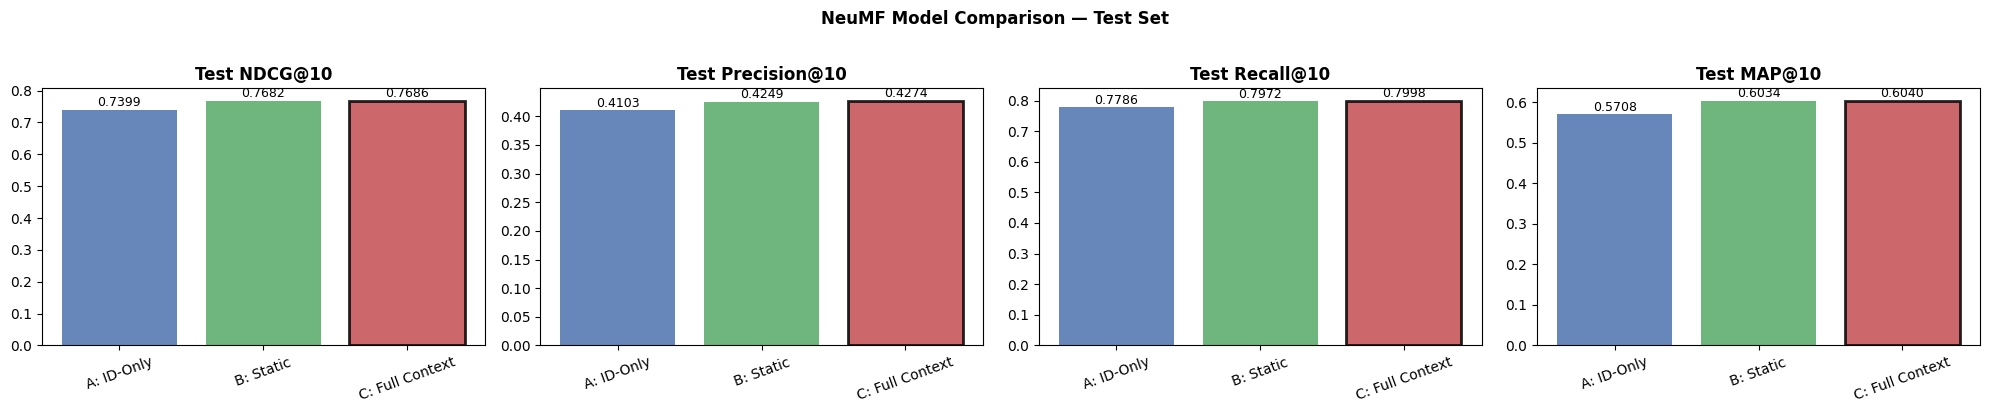


★ Best NeuMF model: B: Static
  Val  NDCG@10 = 0.7603
  Test NDCG@10 = 0.7682


In [31]:
all_model_results = {
    'A: ID-Only':       {'val': val_res_a,  'test': test_res_a},
    'B: Static':        {'val': val_res_b,  'test': test_res_b},
    'C: Full Context':  {'val': val_res_c,  'test': test_res_c},
}
all_preds_val  = {'A': preds_val_a,  'B': preds_val_b,  'C': preds_val_c}
all_preds_test = {'A': preds_test_a, 'B': preds_test_b, 'C': preds_test_c}

# ── Comparison table ──
rows = []
for name, res in all_model_results.items():
    row = {'Model': name}
    for split in ['val','test']:
        for m in ['NDCG@10','Precision@10','Recall@10','HitRate@10','MRR@10','MAP@10',
                  'NDCG@20','CatalogCoverage','UserCoverage']:
            row[f"{split.upper()}_{m}"] = res[split].get(m, 0.0)
        row[f"{split.upper()}_MSE"]  = res[split]['mse']
        row[f"{split.upper()}_RMSE"] = res[split]['rmse']
    rows.append(row)

df_cmp = pd.DataFrame(rows).set_index('Model')
highlight = [c for c in df_cmp.columns if any(
    m in c for m in ['NDCG','Prec','Recall','Hit','MRR','MAP','Coverage'])]
low_cols = [c for c in df_cmp.columns if 'MSE' in c]
display(df_cmp.style
        .highlight_max(subset=highlight, color='#d4edda')
        .highlight_min(subset=low_cols,  color='#d4edda')
        .format(precision=4))

# ── Bar chart ──
metrics_plot = ['NDCG@10','Precision@10','Recall@10','MAP@10']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
names  = list(all_model_results.keys())
colours = ['#4C72B0','#55A868','#C44E52']

for ax, m in zip(axes, metrics_plot):
    vals  = [all_model_results[n]['test'].get(m, 0) for n in names]
    bars  = ax.bar(names, vals, color=colours, alpha=0.85)
    bars[int(np.argmax(vals))].set_edgecolor('black'); bars[int(np.argmax(vals))].set_linewidth(2)
    ax.set_title(f'Test {m}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('NeuMF Model Comparison — Test Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'neumf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Select best ──
best_neumf_key = max(all_model_results,
                     key=lambda k: all_model_results[k]['val']['NDCG@10'])
best_neumf_model = {'A': model_a, 'B': model_b, 'C': model_c}[best_neumf_key[0]]
best_neumf_loader_val  = {'A': val_a,  'B': val_b,  'C': val_c}[best_neumf_key[0]]
best_neumf_loader_test = {'A': test_a, 'B': test_b, 'C': test_c}[best_neumf_key[0]]

print(f"\n★ Best NeuMF model: {best_neumf_key}")
print(f"  Val  NDCG@10 = {all_model_results[best_neumf_key]['val']['NDCG@10']:.4f}")
print(f"  Test NDCG@10 = {all_model_results[best_neumf_key]['test']['NDCG@10']:.4f}")

### 5.11 Training Curves (Best Config per Model)

In [32]:
# Re-run best config for each model to capture history (if not already stored above)
# NOTE: histories are captured inline during grid search. To plot, re-run the best config here.
# This cell is optional if you stored 'hist' from the winning configs above.
print("Training curves are captured during grid search.")
print("To plot, store 'hist' from the winning config iteration above and plot here.")
print()
print("Quick summary of best configs:")
print(f"  Model A: emb={emb_a}, mlp={mlp_a}, drop={drop_a}")
print(f"  Model B: emb={emb_b}, mlp={mlp_b}, drop={drop_b}")
print(f"  Model C: emb={emb_c}, mlp={mlp_c}, drop={drop_c}")

Training curves are captured during grid search.
To plot, store 'hist' from the winning config iteration above and plot here.

Quick summary of best configs:
  Model A: emb=16, mlp=(128, 64), drop=0.3
  Model B: emb=32, mlp=(128, 64), drop=0.3
  Model C: emb=32, mlp=(128, 64), drop=0.3


### 5.12 Caption-Based Filtering Scores for Hybrid

Generate CBF scores using the best config from Notebook 4:
**(F) CN Title + Tags CN, λ = 0.0**

CBF scores are generated for the **val set** (to fit Ridge) and the **test set** (to evaluate hybrid).
The user profiles are built from **training interactions only** — no leakage.

In [33]:
# ── Rebuild user profiles from train ──
# Block-L2-normalise before concatenation (mirrors Notebook 4 exactly)
def _l2_norm(X):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.where(n == 0, 1.0, n)

# Best CBF text embedding: CN title + Tags CN, block-normalised
cbf_emb = np.hstack([_l2_norm(pca_cn_scaled), _l2_norm(pca_tags_scaled)])

CBF_LAMBDA = 0.0   # best λ from Notebook 4

def build_cbf_profiles(interactions_df, text_emb, lam):
    """Weighted average of text embeddings over user's training history."""
    uids   = interactions_df['user_id'].values
    pids   = interactions_df['pid'].values
    wr     = interactions_df['watch_ratio'].values.astype(np.float64)
    et     = interactions_df['exposed_time'].values.astype(np.float64)
    decay  = np.exp(-lam * (et.max() - et) / 86400.0)
    w      = wr * decay

    D       = text_emb.shape[1]
    max_uid = int(uids.max()) + 1
    sum_emb = np.zeros((max_uid, D), dtype=np.float64)
    sum_w   = np.zeros(max_uid,     dtype=np.float64)
    np.add.at(sum_emb, uids, text_emb[pids] * w[:, None])
    np.add.at(sum_w,   uids, w)

    profiles = np.zeros((max_uid, D), dtype=np.float64)
    for uid in np.unique(uids):
        if sum_w[uid] > 0:
            p = sum_emb[uid] / sum_w[uid]
            n = np.linalg.norm(p)
            profiles[uid] = p / n if n > 0 else p
    return profiles


# Build profiles from train interactions
train_eng = pd.read_csv(BASE + 'train_scaled.csv')
cbf_profiles = build_cbf_profiles(train_eng, cbf_emb, CBF_LAMBDA)
print(f"Built CBF profiles for {(cbf_profiles.any(axis=1)).sum():,} users")


def score_cbf(profiles, text_emb, df):
    """Cosine similarity between user profile and video embedding."""
    uids       = df['user_id'].values
    pids       = df['pid'].values
    normed_emb = _l2_norm(text_emb)
    u_vecs     = profiles[uids]
    v_vecs     = normed_emb[pids]
    return np.sum(u_vecs * v_vecs, axis=1).astype(np.float32)


val_eng  = pd.read_csv(BASE + 'val_scaled.csv')
test_eng = pd.read_csv(BASE + 'test_scaled.csv')

cbf_scores_val  = score_cbf(cbf_profiles, cbf_emb, val_eng)
cbf_scores_test = score_cbf(cbf_profiles, cbf_emb, test_eng)

print(f"CBF val  scores: mean={cbf_scores_val.mean():.4f}  std={cbf_scores_val.std():.4f}")
print(f"CBF test scores: mean={cbf_scores_test.mean():.4f}  std={cbf_scores_test.std():.4f}")

Built CBF profiles for 9,665 users
CBF val  scores: mean=0.0697  std=0.1092
CBF test scores: mean=0.0624  std=0.1055


### 5.13 Hybrid Model — Ridge Regression

**Design:**
- Fit NeuMF on Days 1–5 (done above)
- Generate `score_neumf` on **Val set (Day 6)** — these are out-of-sample NeuMF predictions
- Fit Ridge on Val set: target = `watch_ratio`, features = `[score_neumf_norm, score_cbf_norm]`
- Evaluate on **Test set (Day 7)**

**Normalisation:**
- NeuMF output ∈ [0, 2] → divide by 2 → [0, 1]
- CBF cosine ∈ [−1, 1] → (score + 1) / 2 → [0, 1]

This puts both signals on the same scale so Ridge coefficients are directly interpretable:
a higher coefficient = that model is trusted more by Ridge.

In [34]:
# ── NeuMF predictions on val and test ──
preds_val_best  = all_preds_val[best_neumf_key[0]]
preds_test_best = all_preds_test[best_neumf_key[0]]

# ── Normalise to [0, 1] ──
neumf_val_norm  = preds_val_best  / 2.0
neumf_test_norm = preds_test_best / 2.0

cbf_val_norm    = (cbf_scores_val  + 1.0) / 2.0
cbf_test_norm   = (cbf_scores_test + 1.0) / 2.0

# ── Ridge feature matrices ──
X_val  = np.stack([neumf_val_norm,  cbf_val_norm],  axis=1)   # (n_val, 2)
X_test = np.stack([neumf_test_norm, cbf_test_norm], axis=1)   # (n_test, 2)

y_val  = val_eng['watch_ratio'].values
y_test = test_eng['watch_ratio'].values

print(f"Ridge train (val set): X={X_val.shape}, y={y_val.shape}")
print(f"Ridge eval  (test set): X={X_test.shape}, y={y_test.shape}")

# ── Tune Ridge alpha on val set (self-consistency check) ──
# Since we fit and evaluate on the same val set, this just picks the alpha
# that best fits the val data. The real generalisation test is test set.
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
print("\nRidge alpha sweep (fit & score on val):")
for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    ridge.fit(X_val, y_val)
    val_mse = mean_squared_error(y_val, ridge.predict(X_val))
    print(f"  alpha={alpha:<8} val MSE={val_mse:.4f} "          f"coef=[{ridge.coef_[0]:.3f}, {ridge.coef_[1]:.3f}] "          f"intercept={ridge.intercept_:.3f}")

# Use alpha=1.0 (standard default, prevents extreme coefficients)
RIDGE_ALPHA = 1.0
ridge = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
ridge.fit(X_val, y_val)
joblib.dump(ridge, ARTIFACTS + 'hybrid_ridge.pkl')

print(f"\n✓ Ridge fitted (alpha={RIDGE_ALPHA}):")
print(f"  w_neumf = {ridge.coef_[0]:.4f}")
print(f"  w_cbf   = {ridge.coef_[1]:.4f}")
print(f"  bias    = {ridge.intercept_:.4f}")
print(f"  Interpretation: Ridge trusts NeuMF {'more' if ridge.coef_[0] > ridge.coef_[1] else 'less'} "      f"than CBF (ratio {ridge.coef_[0]/max(ridge.coef_[1],1e-6):.2f}x)")

Ridge train (val set): X=(128091, 2), y=(128091,)
Ridge eval  (test set): X=(90650, 2), y=(90650,)

Ridge alpha sweep (fit & score on val):
  alpha=0.001    val MSE=0.2507 coef=[1.729, 0.407] intercept=-0.110
  alpha=0.01     val MSE=0.2507 coef=[1.729, 0.407] intercept=-0.110
  alpha=0.1      val MSE=0.2507 coef=[1.729, 0.407] intercept=-0.110
  alpha=1.0      val MSE=0.2507 coef=[1.728, 0.406] intercept=-0.109
  alpha=10.0     val MSE=0.2507 coef=[1.725, 0.397] intercept=-0.104
  alpha=100.0    val MSE=0.2508 coef=[1.689, 0.329] intercept=-0.058

✓ Ridge fitted (alpha=1.0):
  w_neumf = 1.7282
  w_cbf   = 0.4060
  bias    = -0.1092
  Interpretation: Ridge trusts NeuMF more than CBF (ratio 4.26x)


### 5.14 Hybrid Model Evaluation

In [35]:
# ── Generate hybrid scores on test set ──
hybrid_scores_test = ridge.predict(X_test).astype(np.float32)
hybrid_scores_val  = ridge.predict(X_val).astype(np.float32)

# ── Regression metrics ──
def reg_metrics(preds, targets, label):
    mse  = float(np.mean((preds - targets)**2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(preds - targets)))
    print(f"  {label}: MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return {'mse': mse, 'rmse': rmse, 'mae': mae}

print("=" * 65)
print("HYBRID MODEL — REGRESSION METRICS")
print("=" * 65)
hybrid_reg_val  = reg_metrics(hybrid_scores_val,  y_val,  'VAL')
hybrid_reg_test = reg_metrics(hybrid_scores_test, y_test, 'TEST')

# ── Ranking metrics ──
print("\n" + "=" * 65)
print("HYBRID MODEL — RANKING METRICS")
print("=" * 65)

def rank_eval_from_arrays(scores, split_df, label):
    edf = split_df[['user_id','pid','watch_ratio']].copy()
    edf['predicted_score'] = scores
    res = evaluator.evaluate(edf, K_VALUES, NUM_ITEMS, NUM_USERS)
    evaluator.print_results(label, res, K_VALUES)
    return res

hybrid_rank_val  = rank_eval_from_arrays(hybrid_scores_val,  val_eng,  'Hybrid VAL')
hybrid_rank_test = rank_eval_from_arrays(hybrid_scores_test, test_eng, 'Hybrid TEST')

HYBRID MODEL — REGRESSION METRICS
  VAL: MSE=0.2507  RMSE=0.5007  MAE=0.4046
  TEST: MSE=0.2461  RMSE=0.4960  MAE=0.4024

HYBRID MODEL — RANKING METRICS
  [Hybrid VAL]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7308    0.7610    0.7963    
  Precision       0.5779    0.4711    0.3439    
  Recall          0.5481    0.7352    0.8822    
  HitRate         0.9817    0.9966    0.9994    
  MRR             0.8221    0.8242    0.8244    
  MAP             0.4400    0.5584    0.6471    
  CatalogCoverage: 0.3136 (31.4%)
  UserCoverage   : 0.5303 (53.0%)

  [Hybrid TEST]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.7300    0.7678    0.8072    
  Precision       0.5441    0.4246    0.2927    
  Recall          0.6114    0.7962    0.9235    
  HitRate         0.9825    0.9971    0.9996    
  MRR             0.8168    0.8189    0.8191    
  MAP       

### 5.15 Final Comparison: NeuMF Models vs Hybrid

  FINAL SUMMARY — ALL MODELS


,Val NDCG@10,Val MAP@10,Val MSE,Test NDCG@10,Test MAP@10,Test Recall@10,Test MSE,Test CatalogCov
Model,,,,,,,,
A: ID-Only,0.7262,0.5207,0.2788,0.7399,0.5708,0.7786,0.2696,0.2663
B: Static,0.7603,0.5572,0.2548,0.7682,0.6034,0.7972,0.2502,0.2663
C: Full Context,0.7584,0.5551,0.2503,0.7686,0.6040,0.7998,0.2446,0.2663
Hybrid (NeuMF + CBF),0.7610,0.5584,0.2507,0.7678,0.6030,0.7962,0.2461,0.2663


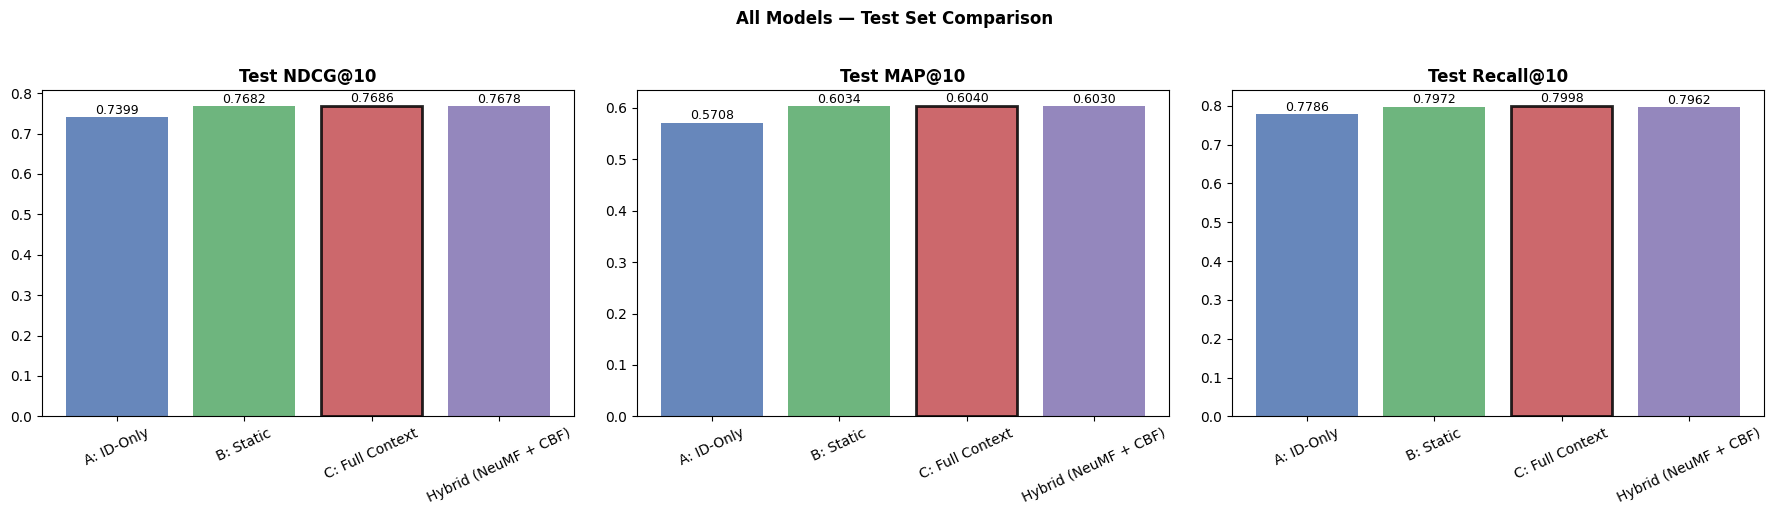


── Ridge Weight Interpretation ──
  w_neumf = 1.7282  (NeuMF normalised score weight)
  w_cbf   = 0.4060  (CBF normalised score weight)
  bias    = -0.1092
  NeuMF contribution: 81.0%
  CBF   contribution: 19.0%

★ Best overall model: C: Full Context
  Test NDCG@10 = 0.7686
  Test MAP@10  = 0.6040


In [36]:
print("=" * 70)
print("  FINAL SUMMARY — ALL MODELS")
print("=" * 70)

summary_rows = []
for name, res in all_model_results.items():
    summary_rows.append({
        'Model': name,
        'Val NDCG@10':  res['val']['NDCG@10'],
        'Val MAP@10':   res['val']['MAP@10'],
        'Val MSE':      res['val']['mse'],
        'Test NDCG@10': res['test']['NDCG@10'],
        'Test MAP@10':  res['test']['MAP@10'],
        'Test Recall@10': res['test']['Recall@10'],
        'Test MSE':     res['test']['mse'],
        'Test CatalogCov': res['test'].get('CatalogCoverage', 0),
    })

# Add hybrid
summary_rows.append({
    'Model': 'Hybrid (NeuMF + CBF)',
    'Val NDCG@10':  hybrid_rank_val['NDCG@10'],
    'Val MAP@10':   hybrid_rank_val['MAP@10'],
    'Val MSE':      hybrid_reg_val['mse'],
    'Test NDCG@10': hybrid_rank_test['NDCG@10'],
    'Test MAP@10':  hybrid_rank_test['MAP@10'],
    'Test Recall@10': hybrid_rank_test['Recall@10'],
    'Test MSE':     hybrid_reg_test['mse'],
    'Test CatalogCov': hybrid_rank_test.get('CatalogCoverage', 0),
})

df_final = pd.DataFrame(summary_rows).set_index('Model')
hi_cols  = [c for c in df_final.columns if 'NDCG' in c or 'MAP' in c or 'Recall' in c or 'Cov' in c]
lo_cols  = [c for c in df_final.columns if 'MSE' in c]
display(df_final.style
        .highlight_max(subset=hi_cols, color='#d4edda')
        .highlight_min(subset=lo_cols, color='#d4edda')
        .format(precision=4))

# ── Bar chart: all models × key metrics ──
models_all = ['A: ID-Only', 'B: Static', 'C: Full Context', 'Hybrid (NeuMF + CBF)']
colours_all = ['#4C72B0','#55A868','#C44E52','#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['Test NDCG@10','Test MAP@10','Test Recall@10']):
    vals = [df_final.loc[m, metric] for m in models_all]
    bars = ax.bar(models_all, vals, color=colours_all, alpha=0.85)
    bars[int(np.argmax(vals))].set_edgecolor('black')
    bars[int(np.argmax(vals))].set_linewidth(2)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('All Models — Test Set Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ridge weight interpretation ──
print("\n── Ridge Weight Interpretation ──")
print(f"  w_neumf = {ridge.coef_[0]:.4f}  (NeuMF normalised score weight)")
print(f"  w_cbf   = {ridge.coef_[1]:.4f}  (CBF normalised score weight)")
print(f"  bias    = {ridge.intercept_:.4f}")
total = abs(ridge.coef_[0]) + abs(ridge.coef_[1])
print(f"  NeuMF contribution: {abs(ridge.coef_[0])/total*100:.1f}%")
print(f"  CBF   contribution: {abs(ridge.coef_[1])/total*100:.1f}%")
print()
best_final = df_final['Test NDCG@10'].idxmax()
print(f"★ Best overall model: {best_final}")
print(f"  Test NDCG@10 = {df_final.loc[best_final,'Test NDCG@10']:.4f}")
print(f"  Test MAP@10  = {df_final.loc[best_final,'Test MAP@10']:.4f}")

In [37]:
# ── Save all artifacts needed by cross_model_evaluation ──
joblib.dump({'emb': emb_a, 'mlp': mlp_a, 'drop': drop_a, 'type': 'A'},
            ARTIFACTS + 'model_a_cfg.pkl')
joblib.dump({'emb': emb_b, 'mlp': mlp_b, 'drop': drop_b, 'type': 'BC'},
            ARTIFACTS + 'model_b_cfg.pkl')
joblib.dump({'emb': emb_c, 'mlp': mlp_c, 'drop': drop_c, 'type': 'BC'},
            ARTIFACTS + 'model_c_cfg.pkl')
joblib.dump({'best_key': best_neumf_key}, ARTIFACTS + 'best_neumf_key.pkl')
joblib.dump({'lambda': CBF_LAMBDA}, ARTIFACTS + 'cbf_config.pkl')

print("✓ Artifacts saved for cross model evaluation:")
print(f"  model_a_cfg.pkl  — emb={emb_a}, mlp={mlp_a}, drop={drop_a}")
print(f"  model_b_cfg.pkl  — emb={emb_b}, mlp={mlp_b}, drop={drop_b}")
print(f"  model_c_cfg.pkl  — emb={emb_c}, mlp={mlp_c}, drop={drop_c}")
print(f"  best_neumf_key.pkl — {best_neumf_key}")
print(f"  cbf_config.pkl   — λ={CBF_LAMBDA}")

✓ Artifacts saved for cross model evaluation:
  model_a_cfg.pkl  — emb=16, mlp=(128, 64), drop=0.3
  model_b_cfg.pkl  — emb=32, mlp=(128, 64), drop=0.3
  model_c_cfg.pkl  — emb=32, mlp=(128, 64), drop=0.3
  best_neumf_key.pkl — B: Static
  cbf_config.pkl   — λ=0.0
